In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 9.4 MB/s eta 0:00:00


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
cap = cv2.VideoCapture("/content/football_jersey_clip.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
ret,frame = cap.read()
ret2, frame2 = cap.read()

In [4]:
def get_centroids(frame):
  result = model.track(frame, persist=True, verbose=False)
  boxes = result[0].boxes.xyxy.cpu().numpy()
  conf = result[0].boxes.conf.cpu().numpy()
  if result[0].boxes.id is None:
    return []
  ids = result[0].boxes.id.cpu().numpy()
  centroid = []
  for box, c, tid in zip(boxes, conf, ids):
    if c < 0.5:
      continue
    x1, y1, x2, y2 = box
    cx = (x1+x2)/2
    cy = (y1+y2)/2
    centroid.append((cx, cy, tid))
  return centroid

test_centroids = get_centroids(frame)
print("get_centroids output:", test_centroids)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 321ms
Prepared 1 package in 84ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

get_centroids output: [(np.float32(403.42545), np.float32(304.4803), np.float32(1.0)), (np.float32(99.70708), np.float32(275.87146), np.float32(2.0)), (np.float32(589.9822), np.float32(353.16367), np.float32(3.0))]


In [5]:
# grab raw boxes once here so jersey-crop/avg-color tests have real data to use
_test_result = model.track(frame, persist=True, verbose=False)
_test_boxes = _test_result[0].boxes.xyxy.cpu().numpy()
print("Sample box for testing:", _test_boxes[0] if len(_test_boxes) else "none detected")

Sample box for testing: [     390.59      284.11      416.26      324.85]


In [6]:
centroid_frame1 = get_centroids(frame)
centroid_frame2 = get_centroids(frame2)

In [7]:
def get_jersey_crop(frame, box):
    x1, y1, x2, y2 = map(int, box)
    height = y2 - y1
    new_y2 = int(y1 + (0.35 * height))
    return frame[y1:new_y2, x1:x2]

test_crop = get_jersey_crop(frame, _test_boxes[0])
print("get_jersey_crop output shape:", test_crop.shape)

get_jersey_crop output shape: (14, 26, 3)


In [8]:
def get_avg_color(crop):
  return crop.mean(axis=(0,1))

test_color = get_avg_color(test_crop)
print("get_avg_color output:", test_color)

get_avg_color output: [      109.7       162.7      140.86]


In [9]:
import math
def get_player_speeds(position_history, fps):
  speeds = []
  for i in range(1, len(position_history)):
    x1, y1 = position_history[i-1]
    x2, y2 = position_history[i]
    distance = math.sqrt((x2-x1)**2 + (y2-y1)**2)
    speeds.append(distance * fps)
  return speeds

test_speeds = get_player_speeds([(0,0),(10,0),(10,10)], fps=30)
print("get_player_speeds output:", test_speeds)

get_player_speeds output: [300.0, 300.0]


In [10]:
def count_sprints(speeds, threshold):
  sprint_count = 0
  was_sprinting = False
  for s in speeds:
    is_sprinting = s > threshold
    if is_sprinting and not was_sprinting:
      sprint_count += 1
    was_sprinting = is_sprinting
  return sprint_count

test_sprints = count_sprints(test_speeds, threshold=100)
print("count_sprints output:", test_sprints)

count_sprints output: 1


In [11]:
def build_player_summary(players_position, player_team, player_distances, fps, sprint_threshold):
  player_summary = {}
  for player_id, pos_history in players_position.items():
    team = player_team.get(player_id, "unknown")
    if not isinstance(team, str):
      team = team.item()
    distance = player_distances[player_id]
    speed = get_player_speeds(pos_history, fps)
    sprint_count = count_sprints(speed, sprint_threshold)
    player_summary[player_id] = {
        "team": team,
        "distance": distance,
        "speed": speed,
        "sprint_count": sprint_count
    }
  return player_summary



In [12]:
model = YOLO('yolov8n.pt')
players_position = {}
tid_color ={}
prev_ids = set()
cap = cv2.VideoCapture("/content/football_jersey_clip.mp4")
frame_count = 0
max_frames = 705

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_count += 1
    if frame_count > max_frames:
        break

    centroid = get_centroids(frame)
    result = model.track(frame, persist=True, verbose=False)
    boxes = result[0].boxes.xyxy.cpu().numpy()
    ids = result[0].boxes.id.cpu().numpy() if result[0].boxes.id is not None else []
    for box, tid in zip(boxes, ids):
        crop = get_jersey_crop(frame, box)
        tid_color[tid] = get_avg_color(crop)
    curr_ids = { tid for cx, cy, tid in centroid }

    for cx, cy, tid in centroid:
        if tid in players_position:
          players_position[tid].append((cx, cy))

        else:
            players_position[tid] = [(cx, cy)]
        disappeared = prev_ids - curr_ids
    new_ids = curr_ids - prev_ids
    if new_ids:
      for t1 in new_ids:
          for t2 in disappeared:
              if t1 not in players_position or t2 not in players_position:
                continue
              dist = np.linalg.norm(tid_color[t1] - tid_color[t2])
              if dist < 15:
                players_position[t2] = players_position[t1]+players_position[t2]
                del players_position[t1]
                print("MATCH:", t1, t2)
                break
              print(t1, t2, dist)
    prev_ids = curr_ids

print("Main loop done. Total tracked ids:", len(players_position))

11.0 5.0 21.57750247809585
5.0 9.0 51.290050602707595
MATCH: 8.0 7.0
12.0 8.0 15.646387993314596
8.0 4.0 19.55375632922316
16.0 4.0 63.18515335467183
16.0 15.0 64.66588511445251
13.0 4.0 48.66152404861862
28.0 25.0 15.437850310915117
28.0 15.0 32.55567972321711
13.0 15.0 81.51603426718657
32.0 25.0 43.8574117851599
29.0 32.0 40.80059634543632
32.0 29.0 36.975063638268615
28.0 36.0 22.439931817515273
28.0 36.0 22.25555017266846
36.0 35.0 24.257873113550303
35.0 32.0 27.982913706476907
35.0 30.0 36.43709668346751
35.0 36.0 17.84037142722496
30.0 36.0 50.296932796262205
36.0 15.0 33.955084232070675
30.0 15.0 21.807828655331534
28.0 36.0 27.939102822484294
30.0 36.0 38.29865489711717
MATCH: 33.0 31.0
30.0 31.0 27.655363495362995
31.0 30.0 23.118253365237628
38.0 31.0 27.715338100094232
39.0 31.0 65.2635593864036
38.0 28.0 49.645980440626595
38.0 30.0 21.814891860913576
MATCH: 39.0 28.0
39.0 30.0 49.67776186244891
MATCH: 30.0 31.0
35.0 30.0 55.498898077042675
35.0 42.0 24.894962938062406
MA

In [13]:
players_position = {pid: pos for pid, pos in players_position.items() if len(pos) >= 5}

In [14]:
player_distances = {}
for pid, history in players_position.items():
    total = 0
    for i in range(len(history) - 1):
        x1, y1 = history[i]
        x2, y2 = history[i+1]
        d = ((x2-x1)**2 + (y2-y1)**2)**0.5
        total += d
    player_distances[pid] = total
print(player_distances)

{np.float32(4.0): np.float32(239.69954), np.float32(5.0): np.float32(672.4744), np.float32(6.0): np.float32(255.9881), np.float32(7.0): np.float32(374.56445), np.float32(9.0): np.float32(50.15697), np.float32(10.0): np.float32(146.47205), np.float32(11.0): np.float32(350.7004), np.float32(12.0): np.float32(92.474846), np.float32(8.0): np.float32(143.48358), np.float32(13.0): np.float32(498.4309), np.float32(14.0): np.float32(527.11926), np.float32(15.0): np.float32(832.75885), np.float32(16.0): np.float32(356.23956), np.float32(23.0): np.float32(44.97624), np.float32(24.0): np.float32(46.852158), np.float32(25.0): np.float32(466.64978), np.float32(27.0): np.float32(255.68674), np.float32(28.0): np.float32(868.21136), np.float32(29.0): np.float32(171.07257), np.float32(31.0): np.float32(2536.225), np.float32(32.0): np.float32(263.22852), np.float32(35.0): np.float32(533.9087), np.float32(36.0): np.float32(220.31947), np.float32(33.0): np.float32(475.603), np.float32(38.0): np.float32(27

In [15]:
colors_only = list(tid_color.values())
ids_only = list(tid_color.keys())
data = np.array(colors_only, dtype=np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
compactness, labels, centers = cv2.kmeans(data, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
player_team = {tid: labels[i][0] for i, tid in enumerate(ids_only)}
print(player_team)

{np.float32(4.0): np.int32(1), np.float32(5.0): np.int32(0), np.float32(6.0): np.int32(1), np.float32(7.0): np.int32(1), np.float32(8.0): np.int32(1), np.float32(9.0): np.int32(1), np.float32(10.0): np.int32(1), np.float32(11.0): np.int32(0), np.float32(12.0): np.int32(0), np.float32(13.0): np.int32(0), np.float32(14.0): np.int32(0), np.float32(15.0): np.int32(1), np.float32(16.0): np.int32(0), np.float32(23.0): np.int32(0), np.float32(24.0): np.int32(0), np.float32(25.0): np.int32(0), np.float32(27.0): np.int32(1), np.float32(28.0): np.int32(0), np.float32(29.0): np.int32(1), np.float32(30.0): np.int32(0), np.float32(31.0): np.int32(1), np.float32(32.0): np.int32(1), np.float32(33.0): np.int32(1), np.float32(35.0): np.int32(1), np.float32(36.0): np.int32(0), np.float32(38.0): np.int32(1), np.float32(39.0): np.int32(0), np.float32(40.0): np.int32(0), np.float32(42.0): np.int32(1), np.float32(43.0): np.int32(1), np.float32(44.0): np.int32(1), np.float32(45.0): np.int32(1), np.float32(46

In [16]:
team_distance = {}
for pid, dist in player_distances.items():
  if pid not in player_team:
    continue
  team = int(player_team[pid])
  if team not in team_distance:
    team_distance[team] = 0
  team_distance[team] += dist
print(team_distance)

{1: np.float32(8836.362), 0: np.float32(11165.573)}


In [17]:
fps = cap.get(cv2.CAP_PROP_FPS)
build_player_summary(players_position, player_team, player_distances, fps, 30)

{np.float32(4.0): {'team': 1,
  'distance': np.float32(239.69954),
  'speed': [1.152453821388687,
   4.890963902933831,
   1.3515198392833099,
   5.765800323508536,
   7.075194285769812,
   2.6605032254823486,
   3.61629373392275,
   2.329030730611947,
   5.082301339002925,
   4.279533526807774,
   3.013962833756257,
   4.373633179711231,
   5.426850057782069,
   6.460169805378035,
   4.591014641692135,
   11.513418756215072,
   9.798944375631851,
   17.233303658430195,
   25.9991583389905,
   17.85986083497105,
   19.658713222808114,
   44.67724075461602,
   53.943054792821265,
   32.46377283009217,
   41.62767513087332,
   65.27670212348666,
   16.25549615474592,
   19.377962355107243,
   45.359884347923796,
   40.20738529741372,
   47.99719467260293,
   46.45209112983229,
   31.456371992538983,
   28.738299456008964,
   31.322314515503543,
   43.976544619915956,
   50.873288596795994,
   44.663515590370636,
   24.36190412310336,
   22.750189481721662,
   25.255765027811115,
   39.98

In [18]:
cap_check = cv2.VideoCapture("/content/football_jersey_clip.mp4")
print(cap_check.get(cv2.CAP_PROP_FRAME_COUNT))

705.0


(460, 819, 3)


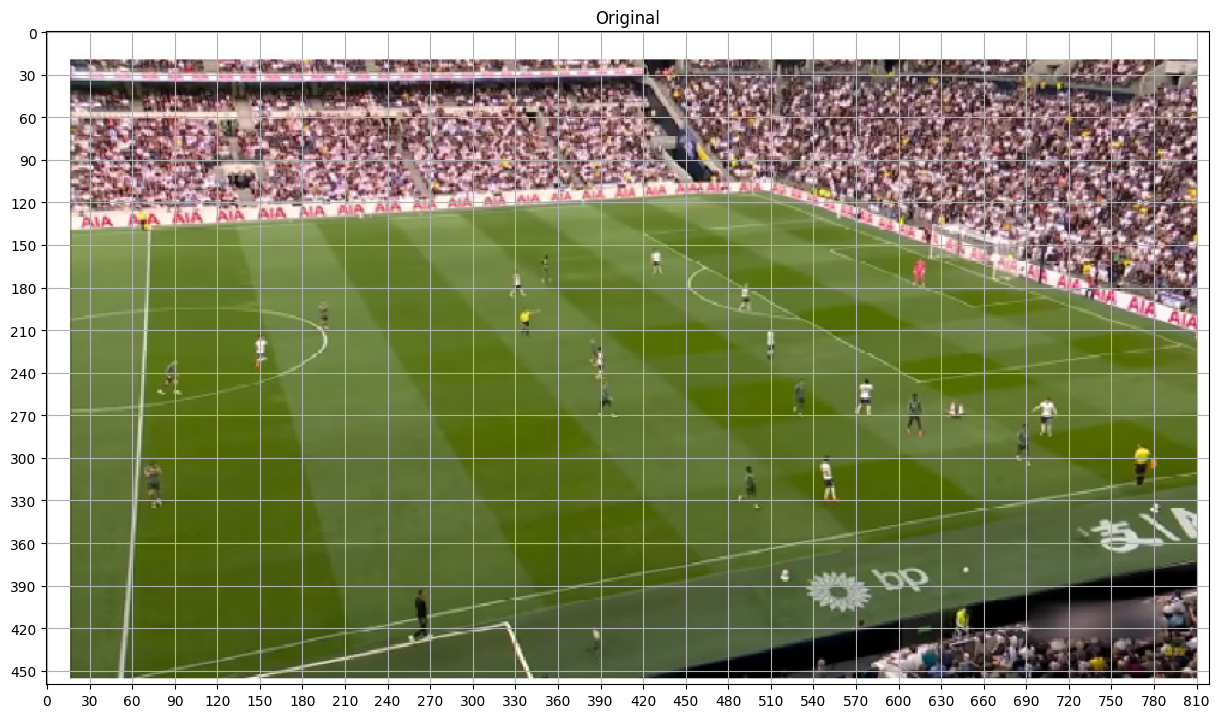

In [19]:
def image_ball(img_path):
  img = cv2.imread(img_path)
  plt.figure(figsize=(15,10))
  plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
  plt.grid(True)
  print(img.shape)
  plt.xticks(range(0,819,30))
  plt.yticks(range(0,460,30))

  plt.title("Original")


detection = image_ball("/content/Tactical_viewofmatch.jpg")

In [20]:
# pixel points from your image (in order: red, purple, blue, orange)
pixel_pts = np.float32([[420,145],[540,130],[600,240],[780,210]])

# matching real-world points in meters, same order
real_pts = np.float32([[-9.15,0],[0,9.15],[9.15,0],[18,-5]])

# solves for the matrix mapping pixel -> real world
matrix = cv2.getPerspectiveTransform(pixel_pts, real_pts)
print(matrix)

[[  -0.012117   -0.060775      14.444]
 [  0.0091131   -0.017267     -1.3238]
 [ 0.00059666  -0.0090337           1]]


In [21]:
pixel_pts = np.float32([[70,452],[70,140],[430,140],[620,240]])
real_pts = np.float32([[0,0],[0,68],[20,68],[20,50]])

matrix = cv2.getPerspectiveTransform(pixel_pts, real_pts)
print(matrix)

[[     2.4435  1.6722e-17     -171.05]
 [     4.3472     -4.5701      1761.4]
 [    0.06393     0.11067           1]]
